## Fit $k(M)$ on new data

Reconstructs the empirical points and re-estimates $a$, $\tau$ in
$k(M)=2\,[1 + a(1 - e^{-M/\tau})]$ from the regenerated pipeline outputs.

- **Fit basis:** weighted consensus. The untransformed weighted consensus is computed
  inline from `12_drugbank` + the per-model weights — no need to run script 14 first,
  since the tanh is applied *after* `_score`.
- **Per-pathogen target $k^*$:** *exact numeric solve* — the $k$ for which the IQR of the
  tanh-transformed weighted consensus equals the average per-model IQR. More principled
  than the closed-form $k\approx2\,\overline{\mathrm{IQR}}/\mathrm{IQR}_\mathrm{cons}$ used previously.
- **Fit:** least squares (`scipy.optimize.curve_fit`) of $k(M)$ to the $(M, k^*)$ points.

Requires: `10_reports.csv` and `12_drugbank/{pathogen}.csv` (one column per model).
After running, copy the printed `_TANH_A` / `_TANH_TAU` into
`scripts/14_consensus_scoring.py` and re-run script 14.

In [32]:
# Reconstruct empirical (M, k*) points from the new pipeline outputs.
# The untransformed weighted consensus is computed inline from 12_drugbank + 10_reports
# (the tanh is applied AFTER _score), so no dependency on script 14 having been run.
import os
import pandas as pd
import numpy as np
from scipy.optimize import brentq, curve_fit, minimize_scalar


def _tanh_transform(x, k):
    return 0.5 + 0.5 * np.tanh(k * (x - 0.5)) / np.tanh(k / 2)


# --- _score from scripts/14_consensus_scoring.py (untransformed weighted consensus) ---
W_COLS    = ["w1", "w2", "w3", "w4", "w5", "w6", "w7"]
W_WEIGHTS = np.ones(len(W_COLS) + 1)


def _compute_w8(prob_ranks, cutoffs):
    c = np.clip(cutoffs[np.newaxis, :], 0.0, 1.0 - 1e-9)
    return np.where(prob_ranks <= c, 0.0, (prob_ranks - c) / (1.0 - c))


def _score(prob_ranks, w_quality, cutoffs):
    w8 = _compute_w8(prob_ranks, cutoffs)
    n_compounds, n_models = prob_ranks.shape
    w_all = np.empty((n_compounds, n_models, len(W_WEIGHTS)))
    w_all[:, :, :len(W_COLS)] = w_quality
    w_all[:, :,  len(W_COLS)] = w8
    w = np.average(w_all, axis=-1, weights=W_WEIGHTS)
    return (prob_ranks * w).sum(axis=1) / w.sum(axis=1)


def _iqr(a):
    a = np.asarray(a, dtype=float)
    return float(np.quantile(a, 0.75) - np.quantile(a, 0.25))


def _solve_k_star(consensus, target_iqr, kmax=80.0):
    """k>0 such that IQR(_tanh_transform(consensus, k)) == target_iqr.

    IQR(k) is monotonic in k only when [Q1, Q3] of `consensus` brackets 0.5.
    Otherwise the curve is hump-shaped: it grows from the untransformed IQR
    up to a peak at some finite k, then collapses to 0 as k→∞ (the tanh
    becomes a step at 0.5 and pushes both quartiles to the same extreme).
    We locate the peak first and search for the target on the ascending side;
    return NaN if the peak itself can't reach target.
    """
    if target_iqr <= _iqr(consensus):
        return 0.0
    iqr_at = lambda k: _iqr(_tanh_transform(consensus, k))
    res = minimize_scalar(lambda k: -iqr_at(k), bounds=(1e-6, kmax), method="bounded")
    k_peak, iqr_peak = float(res.x), -float(res.fun)
    if iqr_peak < target_iqr:
        return float("nan")
    return float(brentq(lambda k: iqr_at(k) - target_iqr, 1e-6, k_peak, xtol=1e-4))


REPORTS = "../output/10_reports/10_reports.csv"
IN12    = "../output/12_drugbank"

reports = pd.read_csv(REPORTS)
rows = []
for pathogen in dict.fromkeys(reports["pathogen"]):
    f12 = f"{IN12}/{pathogen}.csv"
    if not os.path.isfile(f12):
        continue
    df12 = pd.read_csv(f12)
    pre = reports[reports["pathogen"] == pathogen].set_index("model_name")
    model_cols = [c for c in df12.columns if c != "smiles" and c in pre.index]
    if len(model_cols) < 2:
        continue
    prob_ranks    = df12[model_cols].fillna(0.0).values
    w_quality     = np.array([pre.loc[m, W_COLS].values for m in model_cols], dtype=float)
    cutoffs       = np.array([pre.loc[m, "decision_cutoff_rank"] for m in model_cols], dtype=float)
    consensus     = _score(prob_ranks, w_quality, cutoffs)
    avg_model_iqr = float(np.mean([_iqr(prob_ranks[:, j]) for j in range(len(model_cols))]))
    rows.append({
        "pathogen": pathogen, "M": len(model_cols),
        "avg_model_iqr": round(avg_model_iqr, 4),
        "consensus_iqr": round(_iqr(consensus), 4),
        "k_star": round(_solve_k_star(consensus, avg_model_iqr), 4),
    })


points = pd.DataFrame(rows)
points

,pathogen,M,avg_model_iqr,consensus_iqr,k_star
0,abaumannii,7,0.1430,0.0939,4.1113
1,calbicans,33,0.1847,0.0807,4.5370
2,campylobacter,2,0.2063,0.2000,0.6818
3,ecoli,28,0.1713,0.0891,3.7253
4,efaecium,7,0.1704,0.0952,3.9112
5,enterobacter,7,0.1486,0.0803,3.7815
6,hpylori,4,0.1569,0.0891,3.4638
7,kpneumoniae,16,0.1659,0.0949,3.3190
8,mtuberculosis,47,0.2060,0.0829,5.0105
9,ngonorrhoeae,5,0.1754,0.1355,1.9658


# Tanh IQR-restoring transformation (script 14)

Visualises the consensus-score transform applied in `scripts/14_consensus_scoring.py`:

$$f(x) = 0.5 + \frac{0.5 \cdot \tanh(k(x-0.5))}{\tanh(k/2)}$$

for $x \in [0, 1]$. The steepness $k$ depends only on the number of models $M$ via
$k(M) = 2\,[1 + a(1 - e^{-M/\tau})]$. The transform is anchored at $f(0.5)=0.5$, fixes the
endpoints $f(0)=0$ and $f(1)=1$, and is rank-preserving (strictly increasing).

In [29]:
import numpy as np
import stylia
from stylia import save_figure

stylia.set_format("slide")
stylia.set_style("ersilia")

Matplotlib is building the font cache; this may take a moment.


In [33]:
# Constants and transform, copied verbatim from scripts/14_consensus_scoring.py
_TANH_A = 1.156
_TANH_TAU = 6.47


def _k_from_n_models(n: int) -> float:
    """Steepness for the IQR-restoring tanh transform; depends only on number of models."""
    s = 1.0 + _TANH_A * (1.0 - np.exp(-n / _TANH_TAU))
    return 2.0 * s

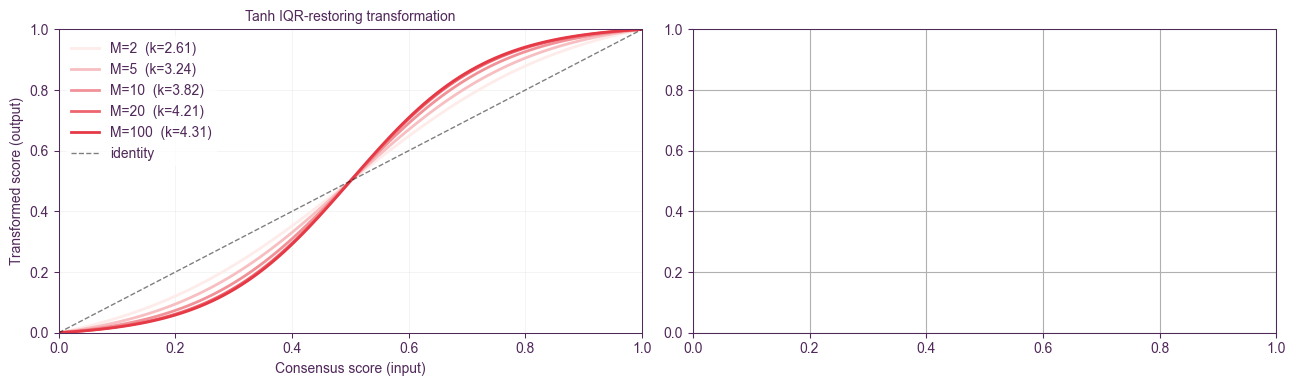

In [31]:
x = np.linspace(0, 1, 100)
M_show = [2, 5, 10, 20, 100]

# One color per M, graded along a stylia continuous colormap.
cmap = stylia.ContinuousColorMap()
cmap.fit(np.array(M_show))
line_colors = cmap.transform(np.array(M_show))

fig, axs = stylia.create_figure(1, 2)
ax = axs.next()

for M, c in zip(M_show, line_colors):
    k = _k_from_n_models(M)
    ax.plot(x, _tanh_transform(x, k), color=c, lw=2, label=f"M={M}  (k={k:.2f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="identity")
ax.set_xlabel("Consensus score (input)")
ax.set_ylabel("Transformed score (output)")
ax.set_title("Tanh IQR-restoring transformation")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left")

# save_figure("../output/14_tanh_transform.png")

In [34]:
# Fit k(M) = 2*(1 + a*(1 - exp(-M/tau))) to the (M, k*) points
fit = points[points["k_star"].notna() & (points["k_star"] > 0)]
Ms, ks = fit["M"].to_numpy(float), fit["k_star"].to_numpy(float)


def _k_model(M, a, tau):
    return 2.0 * (1.0 + a * (1.0 - np.exp(-M / tau)))


(a_hat, tau_hat), _ = curve_fit(
    _k_model, Ms, ks, p0=[_TANH_A, _TANH_TAU],
    bounds=([0.0, 0.1], [10.0, 100.0]), maxfev=20000,
)
rmse = float(np.sqrt(np.mean((ks - _k_model(Ms, a_hat, tau_hat)) ** 2)))

print(f"points used: {len(fit)}")
print(f"NEW     A = {a_hat:.4f}   tau = {tau_hat:.4f}   (RMSE on k = {rmse:.4f})")
print(f"CURRENT A = {_TANH_A}   tau = {_TANH_TAU}")
print(f"\nUpdate scripts/14_consensus_scoring.py:\n  _TANH_A   = {a_hat:.4f}\n  _TANH_TAU = {tau_hat:.4f}")

points used: 15
NEW     A = 1.2784   tau = 11.3942   (RMSE on k = 0.7470)
CURRENT A = 1.156   tau = 6.47

Update scripts/14_consensus_scoring.py:
  _TANH_A   = 1.2784
  _TANH_TAU = 11.3942


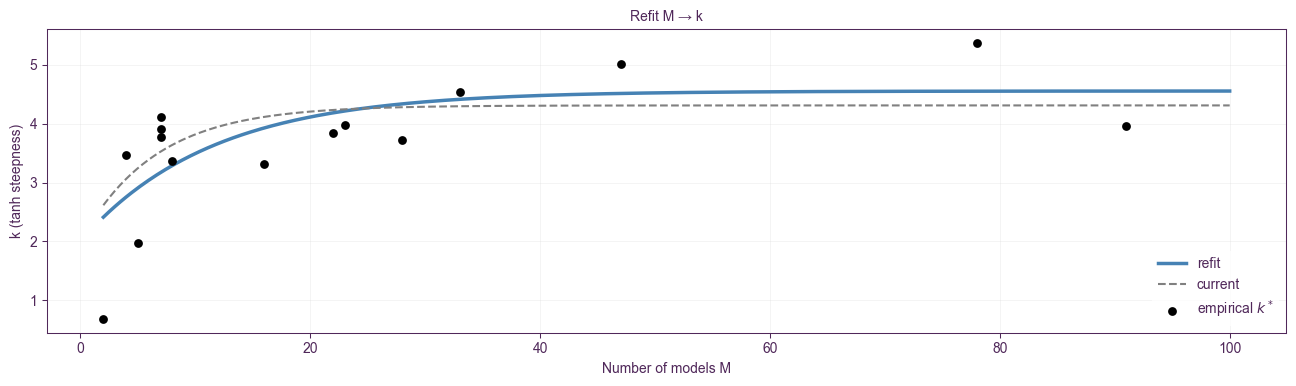

In [ ]:
# Visualise the refit: empirical k* points, refitted curve, and the current curve
M_cont = np.linspace(2, max(100, Ms.max()), 400)

fig, axs = stylia.create_figure(1, 1)
ax = axs.next()
ax.plot(M_cont, _k_model(M_cont, a_hat, tau_hat), color="steelblue", lw=2.5, label="refit")
ax.plot(M_cont, _k_model(M_cont, _TANH_A, _TANH_TAU), color="gray", lw=1.5, ls="--", label="current")
ax.scatter(Ms, ks, color="black", s=40, zorder=5, label=r"empirical $k^*$")
ax.set_xlabel("Number of models M")
ax.set_ylabel("k (tanh steepness)")
ax.set_title("Refit M → k")
ax.legend(loc="lower right")

# save_figure("../output/14_tanh_refit.png")